# Data Preprocessing

This notebook focuses on preparing the rice leaf disease dataset for machine learning model development. The preprocessing workflow transforms the raw YOLO-formatted dataset into a structured, model-ready format suitable for image classification tasks.

Format Transformation: The raw data uses YOLO object detection format (bounding box annotations with class IDs). This notebook extracts the single disease class label from each image's annotation file and organizes the data for single-label multi-class image classification. The bounding box information documents the affected region but is not used by the classification model input.

The notebook includes image preparation, label extraction from YOLO files, dataset organization, image normalization, and augmentation strategy preparation. The preprocessing steps are designed to improve training consistency, mitigate dataset imbalance, and support robust model performance.

The outputs generated in this notebook will be used directly during model training and evaluation.


## Objectives

- Transform raw YOLO-formatted data into image classification-ready format.
- Extract single disease class labels from YOLO annotation files for each image.
- Create structured, balanced training and validation datasets.
- Standardize image dimensions and pixel value normalization.
- Prepare data augmentation strategies to mitigate class imbalance.
- Generate metadata files mapping images to their disease labels.
- Produce processed datasets and summaries for model training.


## Inputs

- Raw rice leaf disease dataset in YOLO format
  (`inputs/datasets/raw/rice/`)
  - Images organized in: `images/train/`, `images/val/`
  - YOLO annotations in: `labels/train/`, `labels/val/`
  - Class mapping in: `data.yaml`

- Outputs generated during exploratory data analysis:
  - `outputs/datasets/eda/class_distribution.csv`
  - `outputs/datasets/eda/image_metadata.csv`


## Outputs

Processed datasets and metadata saved to:

`inputs/datasets/processed/`

Including:
- `train_labels.csv` - Mapping of training images to their single disease class labels
- `val_labels.csv` - Mapping of validation images to their single disease class labels
- Preprocessing summary (class balance, image dimensions, normalization details)
- Augmentation strategy documentation


## Additional Comments

- Label Extraction: YOLO annotation files contain bounding box coordinates and class IDs. This notebook extracts the class ID (single disease type) for each image, treating it as a classification label rather than an object detection annotation.
- Single-Label Assumption: Each image is assigned exactly one disease class label (Healthy or one of 8 disease types). Images are not classified as having multiple diseases.
- Class Imbalance Strategy: Preprocessing prepares augmentation techniques and class weighting strategies to be applied during model training, addressing the documented imbalance.
- Image Standardization: All images are resized and normalized to consistent dimensions and pixel value ranges for model input compatibility.

## Steps to Implement the Notebook

### 1. Load Python Packages and Project Dependencies

This section imports the Python libraries and dependencies required for image preprocessing, dataset manipulation, visualisation, and file handling throughout the notebook.

In [34]:
# Data handling
import pandas as pd
import numpy as np

# File and path handling
from pathlib import Path
import os
import random
import shutil

# Image processing
from PIL import Image

# Data visualisation
import matplotlib.pyplot as plt

# Utility collections
from collections import Counter

# Machine learning utilities
from sklearn.model_selection import train_test_split

# TensorFlow / Keras preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### 2. Set Working Directory

This section configures the notebook working directory to the project root and defines reusable dataset and output paths used throughout preprocessing.

In [35]:
def setup_root():
    current_path = Path().resolve()
    # Search upwards for project root
    while not (current_path / "requirements.txt").exists():
        if current_path == current_path.parent:
            raise FileNotFoundError(
                "Project root not found. Ensure requirements.txt exists."
            )
        current_path = current_path.parent
    return current_path


# Set project root
PROJECT_ROOT = setup_root()

# Change working directory
os.chdir(PROJECT_ROOT)
print(f"Project root set to: {PROJECT_ROOT}")


# Define paths
DATASET_DIR = Path("inputs/datasets/raw/rice")

EDA_OUTPUT_DIR = Path("outputs/datasets/eda")

PROCESSED_DATA_DIR = Path("inputs/datasets/processed")

PREPROCESSING_OUTPUT_DIR = Path(
    "outputs/datasets/preprocessing"
)

# Create output directories if they do not exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

PREPROCESSING_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Dataset directory: {DATASET_DIR}")
print(f"Processed dataset directory: {PROCESSED_DATA_DIR}")
print(f"Preprocessing output directory: {PREPROCESSING_OUTPUT_DIR}")

Project root set to: C:\code\ml\workspace\rice_leaf_diseases_analyser
Dataset directory: inputs\datasets\raw\rice
Processed dataset directory: inputs\datasets\processed
Preprocessing output directory: outputs\datasets\preprocessing


### 3. Load Dataset Metadata

Load outputs generated during the exploratory data analysis notebook for use during preprocessing and dataset preparation.

In [36]:
# Load EDA outputs
class_distribution_path = (
    EDA_OUTPUT_DIR / "class_distribution.csv"
)

image_metadata_path = (
    EDA_OUTPUT_DIR / "image_metadata.csv"
)

df_class_distribution = pd.read_csv(
    class_distribution_path
)

df_image_metadata = pd.read_csv(
    image_metadata_path
)

print("EDA metadata loaded successfully.")

print("\nClass Distribution:")
display(df_class_distribution.head())

print("\nImage Metadata:")
display(df_image_metadata.head())

EDA metadata loaded successfully.

Class Distribution:


,Class,Train Images,Validation Images,Total Images
0,BacterialLeafBlight,1600,400,2000
1,BrownSpot,1600,400,2000
2,Healthy,347,86,433
3,Hispa,345,86,431
4,LeafBlast,360,89,449



Image Metadata:


,image,width,height,aspect_ratio,resolution
0,r6k_test_Blast_1040_jpg.rf.1b4df5035f843e4ece4...,587,587,1.0,587x587
1,r6k_test_Blast_1042_jpg.rf.bd326b9f9af9c1a2ae7...,587,587,1.0,587x587
2,r6k_test_Blast_1048_jpg.rf.6e35f9f409e6f90df0d...,587,587,1.0,587x587
3,r6k_test_Blast_1050_jpg.rf.829589c7deda60d55ed...,587,587,1.0,587x587
4,r6k_test_Blast_1060_jpg.rf.b86783516b1eb84925f...,587,587,1.0,587x587


### 4. Create Classification DataFrames

Generate structured training and validation datasets by linking image paths to their corresponding disease labels. These DataFrames will serve as the foundation for preprocessing and model training workflows.

In [37]:
# Define dataset directories
train_images_dir = DATASET_DIR / "images/train"
val_images_dir = DATASET_DIR / "images/val"

train_labels_dir = DATASET_DIR / "labels/train"
val_labels_dir = DATASET_DIR / "labels/val"


# Class mapping
class_names = {
    0: "BacterialLeafBlight",
    1: "BrownSpot",
    2: "Healthy",
    3: "Hispa",
    4: "LeafBlast",
    5: "LeafScald",
    6: "LeafSmut",
    7: "NarrowBrownLeafSpot",
    8: "NeckBlast"
}

In [38]:
def build_classification_dataframe(labels_dir, images_dir):
    dataset_records = []

    for label_file in labels_dir.glob("*.txt"):

        with open(label_file, "r") as f:
            lines = f.readlines()

        if not lines:
            continue

        # Extract first class ID
        class_id = int(lines[0].split()[0])

        # Match image file
        image_path = None

        for ext in [".jpg", ".jpeg", ".png"]:
            possible_path = (
                images_dir / f"{label_file.stem}{ext}"
            )
            if possible_path.exists():
                image_path = possible_path
                break

        if image_path is None:
            continue

        dataset_records.append({
            "image_path": str(image_path),
            "class_id": class_id,
            "class_name": class_names[class_id]
        })

    return pd.DataFrame(dataset_records)

In [39]:
# Create training dataframe
df_train = build_classification_dataframe(
    train_labels_dir,
    train_images_dir
)

# Create validation dataframe
df_val = build_classification_dataframe(
    val_labels_dir,
    val_images_dir
)

print(f"Training samples: {len(df_train)}")
print(f"Validation samples: {len(df_val)}")

display(df_train.head())

Training samples: 6935
Validation samples: 1730


,image_path,class_id,class_name
0,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
1,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
2,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
3,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
4,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut


### 5. Analyze Class Balance

Analyze class distribution within the classification datasets to identify imbalance that may influence model performance during training and evaluation.

In [40]:
# Training class distribution
train_distribution = (
    df_train["class_name"]
    .value_counts()
    .reset_index()
)

train_distribution.columns = [
    "Class",
    "Train Count"
]

train_distribution

,Class,Train Count
0,LeafSmut,1600
1,BacterialLeafBlight,1600
2,BrownSpot,1600
3,LeafScald,365
4,NeckBlast,363
5,LeafBlast,360
6,NarrowBrownLeafSpot,355
7,Healthy,347
8,Hispa,345


In [41]:
# Validation class distribution
val_distribution = (
    df_val["class_name"]
    .value_counts()
    .reset_index()
)

val_distribution.columns = [
    "Class",
    "Validation Count"
]

val_distribution

,Class,Validation Count
0,LeafSmut,400
1,BacterialLeafBlight,400
2,BrownSpot,400
3,LeafScald,91
4,NeckBlast,90
5,LeafBlast,89
6,NarrowBrownLeafSpot,88
7,Hispa,86
8,Healthy,86


In [42]:
# Merge train and validation distributions
df_balance = pd.merge(
    train_distribution,
    val_distribution,
    on="Class",
    how="outer"
).fillna(0)

df_balance["Total"] = (
    df_balance["Train Count"] +
    df_balance["Validation Count"]
)

df_balance

,Class,Train Count,Validation Count,Total
0,BacterialLeafBlight,1600,400,2000
1,BrownSpot,1600,400,2000
2,Healthy,347,86,433
3,Hispa,345,86,431
4,LeafBlast,360,89,449
5,LeafScald,365,91,456
6,LeafSmut,1600,400,2000
7,NarrowBrownLeafSpot,355,88,443
8,NeckBlast,363,90,453


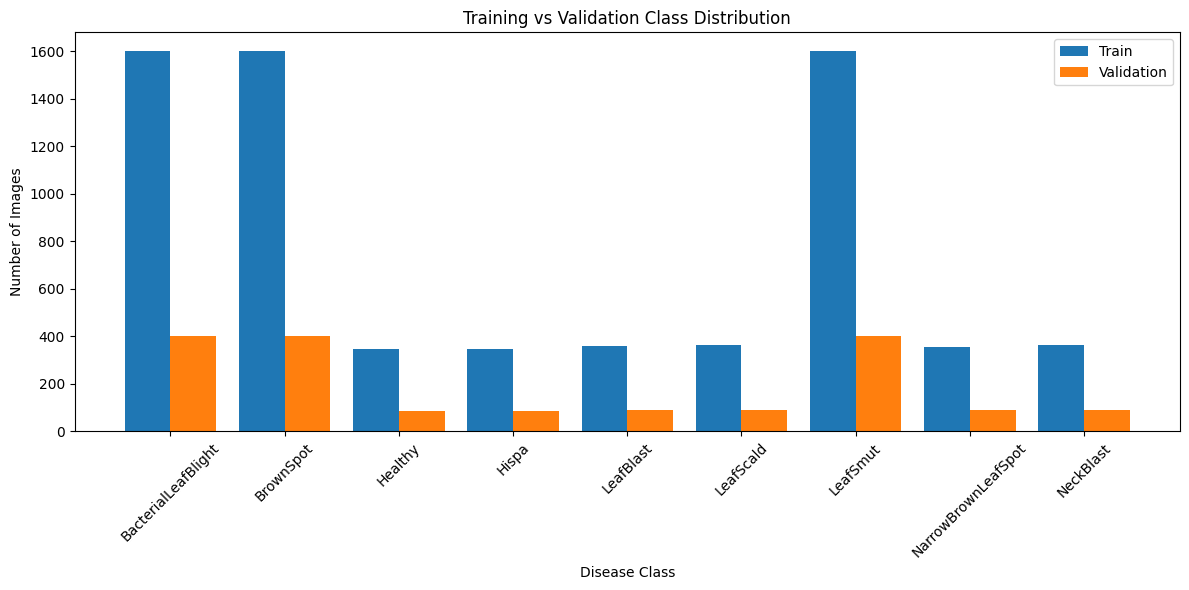

In [43]:
plt.figure(figsize=(12, 6))

x = np.arange(len(df_balance["Class"]))
width = 0.4

plt.bar(
    x - width/2,
    df_balance["Train Count"],
    width,
    label="Train"
)

plt.bar(
    x + width/2,
    df_balance["Validation Count"],
    width,
    label="Validation"
)

plt.xticks(
    x,
    df_balance["Class"],
    rotation=45
)

plt.ylabel("Number of Images")
plt.xlabel("Disease Class")

plt.title(
    "Training vs Validation Class Distribution"
)

plt.legend()

plt.tight_layout()
plt.show()

#### Observations

- The dataset remains noticeably imbalanced after conversion to classification format.
- Certain disease categories contain significantly more images than others.
- Minority classes may be more difficult for the model to learn effectively during training.
- Class imbalance should be considered during preprocessing and model training, potentially through augmentation or weighting strategies.

### 6. Prepare Images for Modeling

Prepare image data for machine learning workflows by standardizing image dimensions and normalizing pixel values. These preprocessing steps help ensure training consistency and improve model performance.

#### Define Target Image Resolution

Resize all images to a consistent resolution suitable for image classification models.

In [44]:
# Target image size
IMAGE_SIZE = (224, 224)

print(f"Target image size: {IMAGE_SIZE}")

Target image size: (224, 224)


In [45]:
def preprocess_image(image_path, target_size=IMAGE_SIZE):

    # Open image
    img = Image.open(image_path).convert("RGB")

    # Resize image
    img = img.resize(target_size)

    # Convert to numpy array
    img_array = np.array(img)

    # Normalize pixel values
    img_array = img_array / 255.0

    return img_array

Test Image Preprocessing

In [46]:
# Select sample image
sample_image_path = df_train.iloc[0]["image_path"]

# Preprocess image
processed_image = preprocess_image(sample_image_path)

print(f"Processed image shape: {processed_image.shape}")
print(f"Pixel value range: "
      f"{processed_image.min():.2f} - "
      f"{processed_image.max():.2f}")

Processed image shape: (224, 224, 3)
Pixel value range: 0.00 - 0.81


Visualize Original vs Processed Image

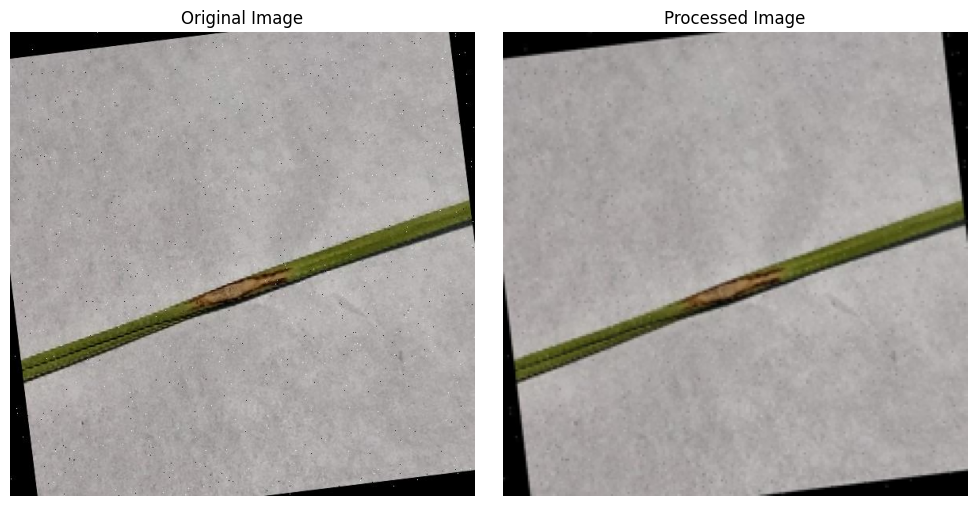

In [47]:
original_image = Image.open(sample_image_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Processed image
axes[1].imshow(processed_image)
axes[1].set_title("Processed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Verify Preprocessing Consistency

In [48]:
sample_batch = random.sample(
    df_train["image_path"].tolist(),
    5
)

for image_path in sample_batch:

    processed = preprocess_image(image_path)

    print(
        f"{Path(image_path).name}: "
        f"{processed.shape}"
    )

rls_train_aug_0_123_jpg.rf.31c9d1dd916594250abf8d41d09bec77.jpg: (224, 224, 3)
rls_train_aug_0_990_jpg.rf.a1f91c5504c18316ac84f51127a45dcd.jpg: (224, 224, 3)
r6k_train_blight_orig_008_PNG_jpg.rf.ce867152a9b078b788a938a5fae8ddf3.jpg: (224, 224, 3)
r6k_train_blast_orig_063_JPG_jpg.rf.ccb42cc24da2a38cbc133834abfe0858.jpg: (224, 224, 3)
rls_train_aug_0_698_jpg.rf.e86f040eda9ed7917d188678dc2fce93.jpg: (224, 224, 3)


#### Observations

- Images were successfully resized to a consistent resolution of `224x224`.
- Pixel values were normalized to the range `[0, 1]`, supporting stable model training.
- The preprocessing pipeline produces consistent image dimensions suitable for convolutional neural networks.
- Standardized preprocessing is expected to improve training efficiency and reduce variability caused by differing image formats.

### 7. Prepare Data Augmentation Strategy

Define data augmentation techniques to improve model robustness and reduce the potential impact of dataset imbalance and visual variability.

Data augmentation artificially increases training diversity by generating modified versions of existing images while preserving disease characteristics relevant for classification.

#### Define Augmentation Configuration

Create an augmentation strategy suitable for rice leaf disease classification tasks.

In [49]:
# Define training data augmentation
train_datagen = ImageDataGenerator(
    
    # Normalize pixel values
    rescale=1./255,
    
    # Augmentations
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    
    # Fill missing pixels after transformations
    fill_mode="nearest"
)

# Validation data should only be normalized
val_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Data augmentation generators created successfully.")

Data augmentation generators created successfully.


#### Visualize Augmented Images

Generate augmented image samples to verify that transformations preserve meaningful disease characteristics.

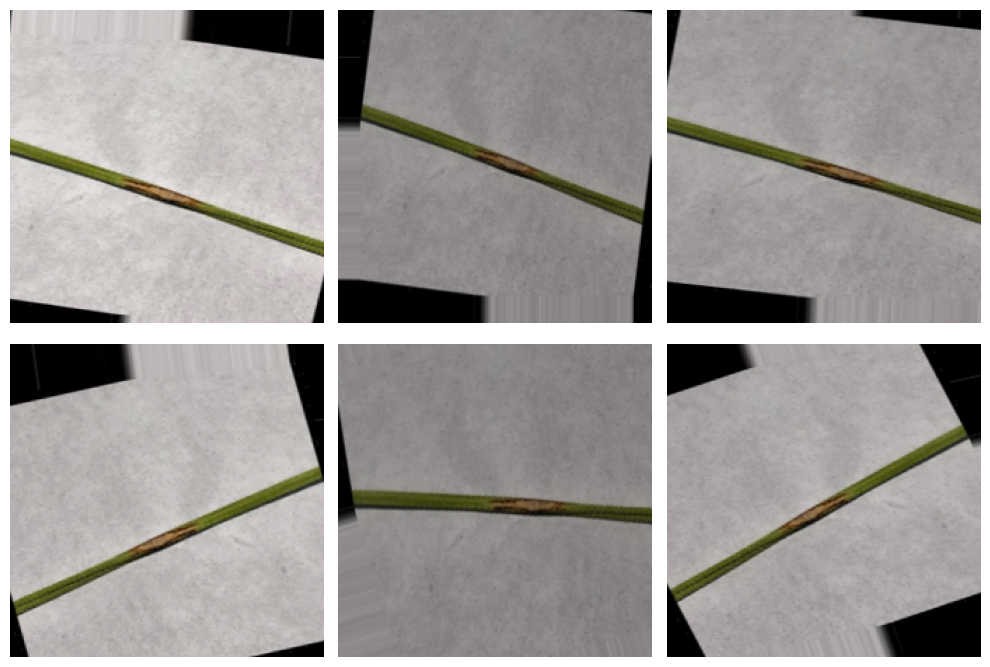

In [50]:
# Load sample image
sample_image = Image.open(sample_image_path).convert("RGB")

# Resize image
sample_image = sample_image.resize(IMAGE_SIZE)

# Convert to array
sample_array = np.array(sample_image)

# Expand dimensions for generator
sample_array = np.expand_dims(sample_array, axis=0)

# Generate augmented samples
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

augmented_images = train_datagen.flow(
    sample_array,
    batch_size=1
)

for ax in axes.flatten():

    augmented_image = next(augmented_images)[0]

    ax.imshow(augmented_image)

    ax.axis("off")

plt.tight_layout()
plt.show()

#### Observations

- The augmentation strategy introduces moderate variation in orientation, brightness, and positioning while preserving key disease characteristics.
- Augmentation is expected to improve model generalization and reduce overfitting during training.
- Brightness and positional transformations may help the model become more robust to varying field conditions and image capture environments.
- Data augmentation may partially mitigate the effects of class imbalance by increasing variability within minority classes.

### 8. Generate Processed Datasets

Generate finalized training and validation datasets prepared for machine learning workflows. The processed datasets will contain standardized image paths and classification labels suitable for model training and evaluation.

#### Prepare Final Training and Validation Datasets

Create finalized metadata tables containing image paths and classification labels for use during model training.

In [51]:
# Final training dataset
df_train_final = df_train.copy()

# Final validation dataset
df_val_final = df_val.copy()

print("Training dataset shape:", df_train_final.shape)
print("Validation dataset shape:", df_val_final.shape)

display(df_train_final.head())

display(df_val_final.head())

Training dataset shape: (6935, 3)
Validation dataset shape: (1730, 3)


,image_path,class_id,class_name
0,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
1,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
2,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
3,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut
4,inputs\datasets\raw\rice\images\train\r6k_test...,6,LeafSmut


,image_path,class_id,class_name
0,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
1,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
2,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
3,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut
4,inputs\datasets\raw\rice\images\val\r6k_test_B...,6,LeafSmut


#### Save Processed Dataset Metadata

In [52]:
# Save processed training metadata
df_train_final.to_csv(
    PROCESSED_DATA_DIR / "train_labels.csv",
    index=False
)

# Save processed validation metadata
df_val_final.to_csv(
    PROCESSED_DATA_DIR / "val_labels.csv",
    index=False
)

print("Processed dataset metadata saved successfully.")

Processed dataset metadata saved successfully.


### 9. Save Preprocessing Outputs

Save preprocessing outputs and summary information for later use during model development and dashboard creation.

In [53]:
# Save class balance summary
df_balance.to_csv(
    PREPROCESSING_OUTPUT_DIR / "class_balance_summary.csv",
    index=False
)

# Save preprocessing configuration summary
preprocessing_summary = pd.DataFrame({
    "parameter": [
        "image_size",
        "normalization",
        "augmentation",
        "train_samples",
        "validation_samples"
    ],
    "value": [
        str(IMAGE_SIZE),
        "Pixel values scaled to [0,1]",
        "Rotation, zoom, shift, brightness, horizontal flip",
        len(df_train_final),
        len(df_val_final)
    ]
})

preprocessing_summary.to_csv(
    PREPROCESSING_OUTPUT_DIR / "preprocessing_summary.csv",
    index=False
)

print("Preprocessing outputs saved successfully.")

Preprocessing outputs saved successfully.


### 10. Summarize Findings

#### Key Findings

- The YOLO object detection dataset was successfully adapted for image classification workflows.
- Structured training and validation datasets were created using image-level disease labels.
- Images were standardized to a consistent resolution of `224x224`.
- Pixel normalization was applied to support stable neural network training.
- Data augmentation strategies were defined to improve model robustness and reduce overfitting.
- Dataset imbalance remains present and may influence model performance for minority classes.

#### Relation to Business Requirements

The preprocessing workflow supports:

- **Business Requirement 1:**  
  Standardized image preparation enables improved visual analysis and disease comparison.

- **Business Requirement 2:**  
  The processed datasets are suitable for training machine learning models capable of classifying rice leaf diseases from images.

#### Conclusions

The dataset has been successfully prepared for machine learning workflows. The preprocessing pipeline produces consistent, normalized, and structured datasets suitable for image classification model development.

The outputs generated in this notebook will be used directly during model training and evaluation.